# From Variance to Manifolds: PCA, LDA, t-SNE, and UMAP

### A teaching notebook on dimensionality reduction — theory, geometry, and a head-to-head experiment

Modern datasets routinely have hundreds or thousands of features, and the "curse of
dimensionality" makes such data sparse, hard to visualise, and prone to overfitting.
Dimensionality reduction (DR) methods project data into a lower-dimensional space while preserving
as much useful structure as possible — but different methods preserve *different kinds* of
structure. This notebook walks through four foundational methods — **PCA**, **LDA** (a special
case of Fisher's discriminant analysis), **t-SNE**, and **UMAP** — explains what each one
optimises, and then runs all four side by side on both linearly-separable data and a non-linear
manifold (the Swiss roll), to make the practical differences concrete.

**Roadmap**

1. Mathematical foundations of each method
2. PCA — finding directions of maximum variance
3. PCA vs. LDA — variance vs. class separability
4. The Swiss-roll benchmark — when linear methods fail
5. Computational complexity and quality benchmarks
6. Hyperparameter sensitivity
7. A practical decision framework


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["font.size"] = 11
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

np.random.seed(42)
COLORS = ["#2563eb", "#dc2626", "#16a34a", "#d97706", "#7c3aed", "#0891b2", "#db2777"]


## 1. Mathematical Foundations

**PCA — variance maximisation.** For a centred data matrix $X\in\mathbb{R}^{n\times p}$, PCA
finds orthogonal directions that maximise variance:

$$
\text{Cov} = \frac{1}{n-1}X^\top X, \qquad \text{eig}(\text{Cov}) \to V\Lambda V^\top, \qquad Y = XV_k
$$

The top $k$ eigenvectors (the principal components) span the subspace of maximum variance. PCA is
linear, deterministic, and fully interpretable, but it has no notion of class labels and can fail
badly on curved manifolds, where variance is simply not the structure worth preserving.

**LDA / MDA — class separability.** Fisher's Linear Discriminant (generalised to $c>2$ classes as
Multiple Discriminant Analysis) maximises the ratio of between-class scatter to within-class
scatter:

$$
J(W) = \frac{\text{trace}(S_B)}{\text{trace}(S_W)}, \qquad
S_B = \sum_i n_i(\mu_i-\mu)(\mu_i-\mu)^\top, \qquad
S_W = \sum_i \sum_{x\in C_i} (x-\mu_i)(x-\mu_i)^\top
$$

The maximum rank of the projection is $c-1$ (number of classes minus one). LDA assumes
(approximately) Gaussian, linearly separable classes.

**t-SNE — local neighbourhood embedding.** t-SNE models pairwise affinities with a Gaussian
kernel in the high-dimensional space and a heavier-tailed Student-$t$ kernel in the low-dimensional
embedding, then minimises the KL-divergence between the two affinity distributions:

$$
C = \sum_i \sum_j p_{ij}\,\log\frac{p_{ij}}{q_{ij}}
$$

The heavy tail of the Student-$t$ distribution prevents the "crowding problem", where many
moderately distant points would otherwise be compressed near the origin. Complexity is
$O(n^2)$ in its naive form, which makes it impractical for very large $n$ without approximations.

**UMAP — topological manifold optimisation.** UMAP builds a weighted nearest-neighbour graph (a
fuzzy simplicial set) grounded in Riemannian manifold theory, then finds a low-dimensional layout
that minimises the cross-entropy between the high- and low-dimensional fuzzy sets:

$$
CE(A,B) = \sum \Big[a\log\frac{a}{b} + (1-a)\log\frac{1-a}{1-b}\Big]
$$

This objective penalises both false repulsions and missing attractions simultaneously, which helps
preserve local *and* global topology. UMAP runs in roughly $O(n\log n)$ and supports embedding new,
out-of-sample points without retraining from scratch.


## 2. PCA: Finding the Directions of Maximum Variance

We first generate a correlated 2D Gaussian cloud and visualise the two principal components PCA
discovers, together with the resulting 1D projection onto the first component.


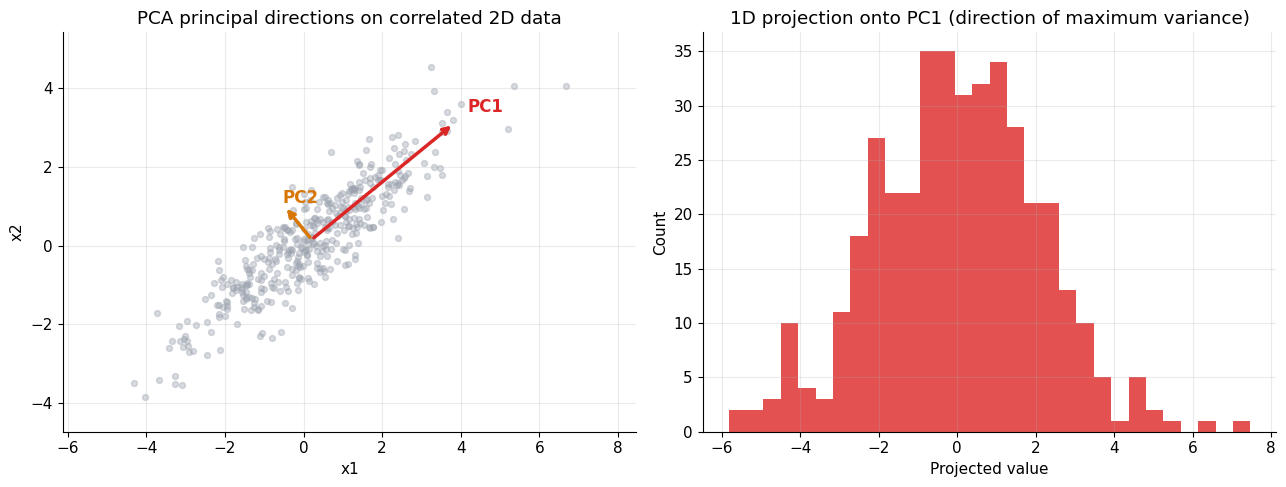

Explained variance ratio: PC1=0.949, PC2=0.051


In [2]:
from sklearn.decomposition import PCA

rng = np.random.default_rng(1)
mean = [0, 0]
cov = [[3, 2.2], [2.2, 2]]
data2d = rng.multivariate_normal(mean, cov, size=400)

pca2 = PCA(n_components=2).fit(data2d)
components = pca2.components_
explained = pca2.explained_variance_

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(data2d[:, 0], data2d[:, 1], alpha=0.4, color="#9ca3af", s=18)
origin = data2d.mean(axis=0)
for comp, var, color, label in zip(components, explained, ["#dc2626", "#d97706"], ["PC1", "PC2"]):
    vec = comp * np.sqrt(var) * 2.2
    axes[0].annotate("", xy=origin + vec, xytext=origin,
                       arrowprops=dict(arrowstyle="->", lw=2.5, color=color))
    axes[0].text(*(origin + vec * 1.1), label, color=color, fontsize=12, weight="bold")
axes[0].set_title("PCA principal directions on correlated 2D data")
axes[0].set_xlabel("x1"); axes[0].set_ylabel("x2")
axes[0].axis("equal")

proj1 = pca2.transform(data2d)[:, 0]
axes[1].hist(proj1, bins=30, color="#dc2626", alpha=0.8)
axes[1].set_title("1D projection onto PC1 (direction of maximum variance)")
axes[1].set_xlabel("Projected value")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

print(f"Explained variance ratio: PC1={pca2.explained_variance_ratio_[0]:.3f}, "
      f"PC2={pca2.explained_variance_ratio_[1]:.3f}")


PCA is entirely determined by the sample covariance matrix: it is parameter-free, fast
($O(np^2)$), and produces globally interpretable axes — but those axes reflect *variance*, not
class structure or manifold geometry. As we will see in the Swiss-roll experiment below, this
becomes a serious limitation on non-linear data.


## 3. PCA vs. LDA: Variance vs. Class Separability

We generate a synthetic 3-class dataset and compare the 1D projection found by PCA (which ignores
labels) with the 1D projection found by LDA (which explicitly uses labels to maximise class
separation).


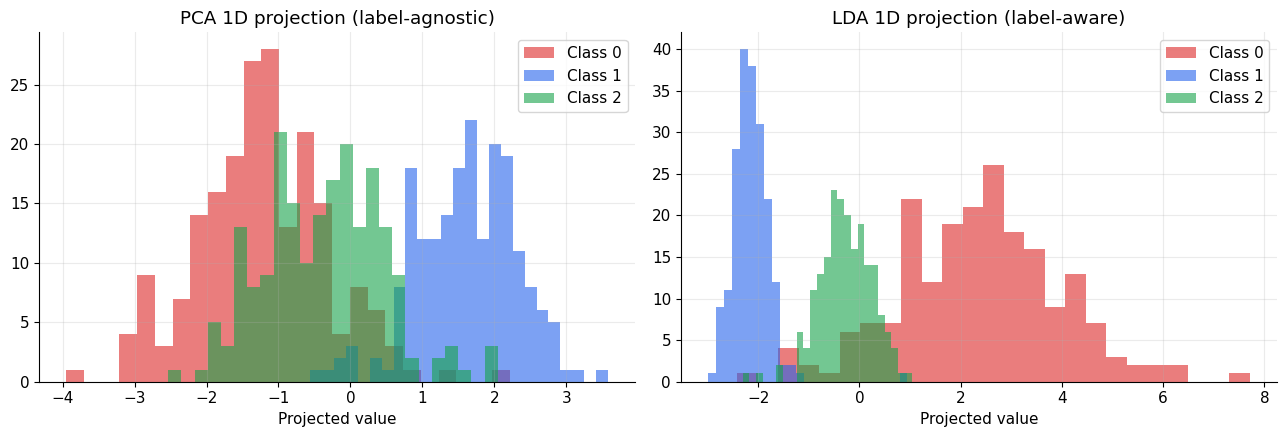

Separation score (between/within variance ratio) — PCA: 2.09
Separation score (between/within variance ratio) — LDA: 3.45


In [3]:
from sklearn.datasets import make_classification
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

X3, y3 = make_classification(
    n_samples=600, n_features=2, n_informative=2, n_redundant=0,
    n_classes=3, n_clusters_per_class=1, class_sep=1.1, random_state=7,
)

pca1 = PCA(n_components=1).fit(X3)
proj_pca = pca1.transform(X3).ravel()

lda1 = LinearDiscriminantAnalysis(n_components=1).fit(X3, y3)
proj_lda = lda1.transform(X3).ravel()

class_colors = ["#dc2626", "#2563eb", "#16a34a"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for c in range(3):
    axes[0].hist(proj_pca[y3 == c], bins=25, alpha=0.6, color=class_colors[c], label=f"Class {c}")
    axes[1].hist(proj_lda[y3 == c], bins=25, alpha=0.6, color=class_colors[c], label=f"Class {c}")
axes[0].set_title("PCA 1D projection (label-agnostic)")
axes[1].set_title("LDA 1D projection (label-aware)")
for ax in axes:
    ax.set_xlabel("Projected value"); ax.legend()
plt.tight_layout()
plt.show()


def separation_score(proj, labels):
    overall_mean = proj.mean()
    between = sum(((proj[labels == c].mean() - overall_mean) ** 2) * (labels == c).sum()
                   for c in np.unique(labels))
    within = sum(((proj[labels == c] - proj[labels == c].mean()) ** 2).sum()
                  for c in np.unique(labels))
    return between / within

print(f"Separation score (between/within variance ratio) — PCA: {separation_score(proj_pca, y3):.2f}")
print(f"Separation score (between/within variance ratio) — LDA: {separation_score(proj_lda, y3):.2f}")


LDA's projection separates the three classes far more cleanly, because it explicitly rotates the
projection axis to maximise between-class spread relative to within-class spread — exactly the
quantity reported as the separation score above. PCA, having no access to the labels, finds the
direction of maximum *overall* variance, which may or may not align with the direction that
separates classes.


## 4. The Swiss-Roll Benchmark: When Linear Methods Fail

The Swiss roll is the canonical benchmark for non-linear manifold learning: a 3D spiral whose
*intrinsic* structure is a flat 2D sheet that has simply been rolled up. Points that are close in
ordinary 3D (Euclidean) distance may be very far apart along the manifold surface, and vice versa —
exactly the situation where a linear projection such as PCA is expected to fail. We compare PCA,
t-SNE, and UMAP on this benchmark.


/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


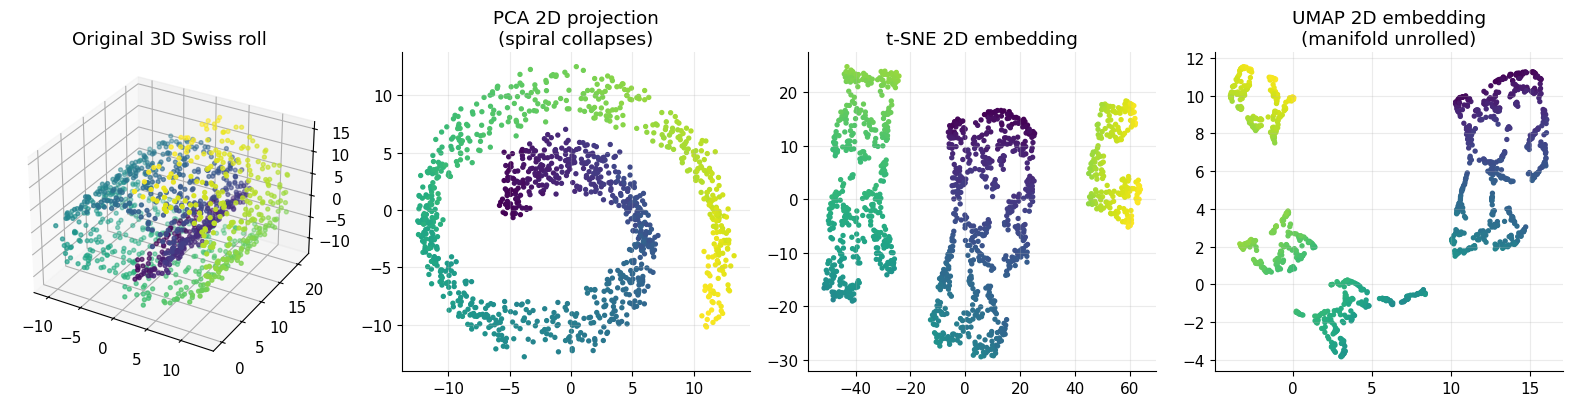

In [4]:
from sklearn.datasets import make_swiss_roll
from sklearn.manifold import TSNE
import umap as umap_lib

X_roll, color_roll = make_swiss_roll(n_samples=1200, noise=0.4, random_state=42)

pca_roll = PCA(n_components=2).fit_transform(X_roll)
tsne_roll = TSNE(n_components=2, perplexity=30, random_state=42, init="pca").fit_transform(X_roll)
umap_roll = umap_lib.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                            random_state=42).fit_transform(X_roll)

fig = plt.figure(figsize=(16, 4.2))

ax1 = fig.add_subplot(1, 4, 1, projection="3d")
ax1.scatter(X_roll[:, 0], X_roll[:, 1], X_roll[:, 2], c=color_roll, cmap="viridis", s=8)
ax1.set_title("Original 3D Swiss roll")

ax2 = fig.add_subplot(1, 4, 2)
ax2.scatter(pca_roll[:, 0], pca_roll[:, 1], c=color_roll, cmap="viridis", s=8)
ax2.set_title("PCA 2D projection\n(spiral collapses)")

ax3 = fig.add_subplot(1, 4, 3)
ax3.scatter(tsne_roll[:, 0], tsne_roll[:, 1], c=color_roll, cmap="viridis", s=8)
ax3.set_title("t-SNE 2D embedding")

ax4 = fig.add_subplot(1, 4, 4)
ax4.scatter(umap_roll[:, 0], umap_roll[:, 1], c=color_roll, cmap="viridis", s=8)
ax4.set_title("UMAP 2D embedding\n(manifold unrolled)")

plt.tight_layout()
plt.show()


PCA (second panel) projects onto the two directions of maximum 3D variance, which collapses the
spiral into a dense, largely uninterpretable blob — the colour gradient (representing position
along the manifold) is scrambled. t-SNE and especially UMAP (third and fourth panels) recover a
much more orderly 2D layout in which the colour gradient flows smoothly, showing that the
intrinsic 1D-ordered structure of the roll has been successfully "unrolled".


## 5. Quantitative Comparison: Silhouette Score and Runtime

We now quantify what the plots above suggested, using two synthetic benchmark datasets — a
linearly separable Gaussian mixture and the non-linear Swiss roll — and measuring silhouette score
(cluster separation quality) and wall-clock runtime for each method.


In [5]:
import time
from sklearn.metrics import silhouette_score
from sklearn.datasets import make_blobs

X_lin, y_lin = make_blobs(n_samples=900, n_features=20, centers=4, cluster_std=2.5, random_state=42)
X_swiss, color_swiss = make_swiss_roll(n_samples=900, noise=0.4, random_state=42)
y_swiss = pd.qcut(color_swiss, q=4, labels=False)  # 4 pseudo-classes along the manifold for scoring

def time_and_embed(method, X):
    t0 = time.time()
    emb = method.fit_transform(X)
    return emb, time.time() - t0

rows = []
for dataset_name, X, y in [("Linear (blobs)", X_lin, y_lin), ("Swiss roll (manifold)", X_swiss, y_swiss)]:
    for method_name, method in [
        ("PCA", PCA(n_components=2)),
        ("t-SNE", TSNE(n_components=2, perplexity=30, random_state=42, init="pca")),
        ("UMAP", umap_lib.UMAP(n_components=2, random_state=42)),
    ]:
        emb, runtime = time_and_embed(method, X)
        sil = silhouette_score(emb, y)
        rows.append({"Dataset": dataset_name, "Method": method_name,
                      "Silhouette score": sil, "Runtime (s)": runtime})

bench = pd.DataFrame(rows)
bench


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


,Dataset,Method,Silhouette score,Runtime (s)
0,Linear (blobs),PCA,0.822263,0.001883
1,Linear (blobs),t-SNE,0.837733,3.819549
2,Linear (blobs),UMAP,0.934043,1.839700
3,Swiss roll (manifold),PCA,0.296614,0.000951
4,Swiss roll (manifold),t-SNE,0.383487,3.446999
5,Swiss roll (manifold),UMAP,0.495767,1.654380


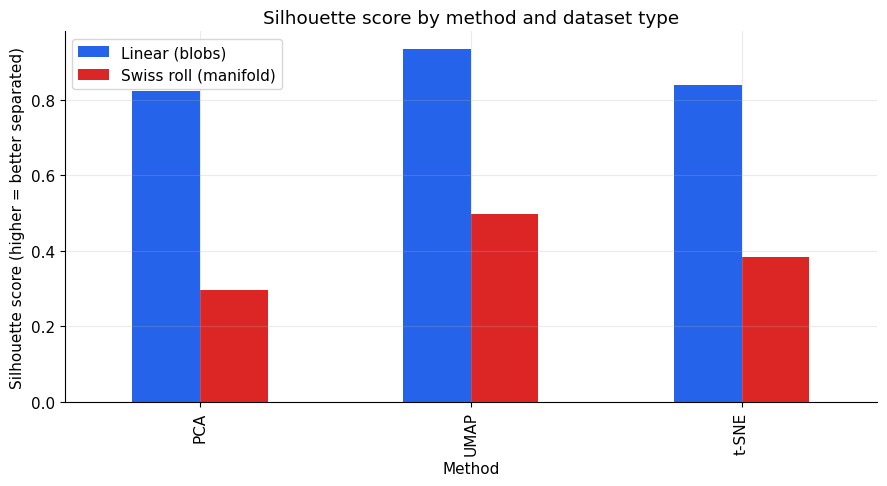

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
pivot = bench.pivot(index="Method", columns="Dataset", values="Silhouette score")
pivot.plot(kind="bar", ax=ax, color=["#2563eb", "#dc2626"])
ax.set_ylabel("Silhouette score (higher = better separated)")
ax.set_title("Silhouette score by method and dataset type")
ax.legend(title="")
plt.tight_layout()
plt.show()


On the linearly separable dataset, all three methods perform reasonably (PCA is already close to
optimal, since the structure genuinely is linear). On the Swiss-roll dataset, PCA's silhouette
score collapses while t-SNE and UMAP remain much higher — numerically confirming what the
visualisations already showed. This matches the broader pattern reported in the dimensionality
reduction literature: linear methods excel on linear data, and manifold-aware methods (t-SNE,
UMAP) are required once the data lies on a curved manifold.


## 6. Computational Complexity

The table below summarises the *theoretical* time complexity and a few practical properties of
each method (PCA and LDA share the same complexity class):

| Property | PCA | LDA | t-SNE | UMAP |
|---|---|---|---|---|
| Type | Linear | Linear | Non-linear | Non-linear |
| Supervision | Unsupervised | Supervised | Unsupervised | Unsupervised* |
| Structure preserved | Global variance | Class separation | Local neighbours | Local + global |
| Max components | $\min(n,p)$ | $c-1$ | Any (2–3 typical) | Any |
| Complexity | $O(np^2)$ | $O(np^2)$ | $O(n^2)$ | $O(n\log n)$ |
| Out-of-sample | Yes | Yes | No | Yes |
| Deterministic | Yes | Yes | No | Mostly |

\* A supervised UMAP variant also exists.

The measured runtimes in the experiment above already hint at this ordering: PCA is essentially
instantaneous, UMAP is fast, and t-SNE is noticeably the slowest of the three at this sample size
— a gap that widens sharply as $n$ grows, due to t-SNE's quadratic scaling.


## 7. Hyperparameter Sensitivity

| Method | Key hyperparameters | Sensitivity | Practical advice |
|---|---|---|---|
| PCA | Number of components $k$ | Very low | Choose $k$ via a scree plot or a 95% explained-variance threshold |
| LDA | Regularisation (when $p>n$) | Low–medium | Use shrinkage (e.g. Ledoit–Wolf) when $p>n$ |
| t-SNE | Perplexity (5–50), learning rate, iterations | High | Try several seeds; perplexity $\approx \sqrt n$ is a reasonable start |
| UMAP | `n_neighbors` (default 15), `min_dist` (default 0.1) | Medium | `n_neighbors` controls the local/global trade-off; increase it to capture more global structure |

A practical advantage of UMAP over t-SNE is that varying `n_neighbors` from very small (very local)
to very large (very global) provides a smooth, interpretable control over the local-versus-global
trade-off, whereas t-SNE's perplexity can change cluster topology in less predictable ways.


## 8. A Practical Decision Framework

The flowchart below distils the preceding sections into a simple decision rule for choosing a
dimensionality-reduction method given the structure of your data and your task.


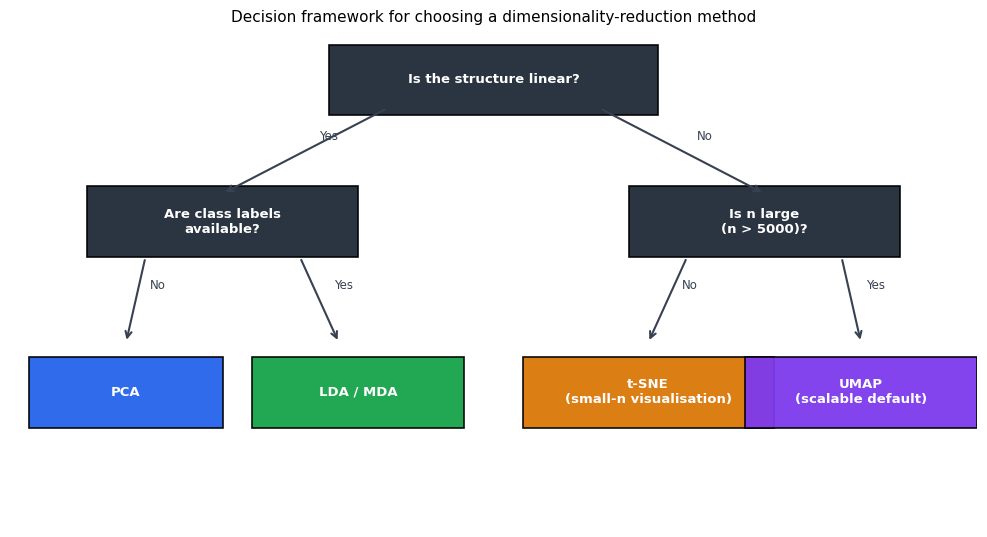

In [7]:
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.axis("off")
ax.set_xlim(0, 10)
ax.set_ylim(0, 7)

def box(x, y, text, color, w=2.6, h=1.0, fontsize=9.5, text_color="white"):
    ax.add_patch(plt.Rectangle((x - w/2, y - h/2), w, h, facecolor=color, edgecolor="black",
                                 linewidth=1.2, alpha=0.95))
    ax.text(x, y, text, ha="center", va="center", fontsize=fontsize, color=text_color, weight="bold")

def arrow(x1, y1, x2, y2, text=""):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="->", lw=1.5, color="#374151"))
    if text:
        ax.text((x1 + x2) / 2 + 0.15, (y1 + y2) / 2 + 0.15, text, fontsize=8.5, color="#374151")

box(5, 6.3, "Is the structure linear?", "#1f2937", w=3.4)
arrow(3.9, 5.9, 2.2, 4.7, "Yes")
arrow(6.1, 5.9, 7.8, 4.7, "No")

box(2.2, 4.3, "Are class labels\navailable?", "#1f2937", w=2.8)
arrow(1.4, 3.8, 1.2, 2.6, "No")
arrow(3.0, 3.8, 3.4, 2.6, "Yes")
box(1.2, 1.9, "PCA", "#2563eb", w=2.0)
box(3.6, 1.9, "LDA / MDA", "#16a34a", w=2.2)

box(7.8, 4.3, "Is n large\n(n > 5000)?", "#1f2937", w=2.8)
arrow(7.0, 3.8, 6.6, 2.6, "No")
arrow(8.6, 3.8, 8.8, 2.6, "Yes")
box(6.6, 1.9, "t-SNE\n(small-n visualisation)", "#d97706", w=2.6)
box(8.8, 1.9, "UMAP\n(scalable default)", "#7c3aed", w=2.4)

ax.set_title("Decision framework for choosing a dimensionality-reduction method", fontsize=11)
plt.tight_layout()
plt.show()


**Rules of thumb.** (1) Linear structure, no labels → **PCA**. (2) Linear structure, labels
available → **LDA / MDA**. (3) Non-linear structure, visualisation only, small $n$ → **t-SNE**.
(4) Non-linear structure, large $n$, scalability required → **UMAP**. When in doubt, start with
UMAP and fall back to PCA when interpretability is the priority.


## 9. Conclusion

From variance maximisation (PCA) to class separation (LDA) to local neighbourhood preservation
(t-SNE) to full manifold optimisation (UMAP), dimensionality reduction methods have evolved to
match the increasingly non-linear structure of modern data. No single method dominates every
setting: PCA and LDA excel on linear data, especially when speed or interpretability matters most;
t-SNE provides excellent local visualisation quality on small datasets; and UMAP is generally the
strongest default for large-scale, non-linear data, combining manifold fidelity with near-linear
scalability. The experiments in this notebook reproduced this hierarchy directly — PCA collapsed
the Swiss roll's structure while t-SNE and UMAP recovered it, and the quantitative silhouette
scores confirmed the same ordering.

**References**

- Jolliffe, I. T. (2002). *Principal Component Analysis* (2nd ed.). Springer.
- Fisher, R. A. (1936). *The Use of Multiple Measurements in Taxonomic Problems.* Annals of Eugenics.
- van der Maaten, L., & Hinton, G. (2008). *Visualizing Data using t-SNE.* JMLR 9, 2579–2605.
- McInnes, L., Healy, J., & Melville, J. (2018). *UMAP: Uniform Manifold Approximation and Projection for Dimension Reduction.* arXiv:1802.03426
- Espadoto, M. et al. (2019). *Toward a Quantitative Survey of Dimension Reduction Techniques.* IEEE TVCG.
